In [81]:
import pandas as pd

In [82]:
data = pd.read_csv('one stack_data.csv')
old = pd.read_csv('previous_data.csv')
old

,Y_vals,mask_id,Stain,X_vals,file_name,DJID,Eye,eGFP_Value,eGFP_Raw_Intensity,in_rip
0,"91001, 94476, 97702, 99241, 106455, 108952, 11...",0,DAPI,"0.0, 0.15, 0.3, 0.44999999999999996, 0.6, 0.75...",2006L_GLUT1_647_WGA_594_0001,2006,L,True,60.608448,False
1,"25935, 27691, 32102, 33195, 41392, 45646, 5084...",0,eGFP,"0.0, 0.15, 0.3, 0.44999999999999996, 0.6, 0.75...",2006L_GLUT1_647_WGA_594_0001,2006,L,True,60.608448,False
2,"164618, 200794, 266470, 281358, 314684, 302362...",0,WGA,"0.0, 0.15, 0.3, 0.44999999999999996, 0.6, 0.75...",2006L_GLUT1_647_WGA_594_0001,2006,L,True,60.608448,False
3,"9783, 11396, 14458, 15066, 18389, 19341, 19969...",0,GluT1,"0.0, 0.15, 0.3, 0.44999999999999996, 0.6, 0.75...",2006L_GLUT1_647_WGA_594_0001,2006,L,True,60.608448,False
4,"46406, 47492, 49547, 50177, 53376, 55141, 5664...",1,DAPI,"0.0, 0.15, 0.3, 0.44999999999999996, 0.6, 0.75...",2006L_GLUT1_647_WGA_594_0001,2006,L,False,6.785691,False
...,...,...,...,...,...,...,...,...,...,...
7291,"2077, 2423, 3057, 3600, 4853, 5987, 9231, 1536...",68,GluT1,"0.0, 0.15, 0.3, 0.44999999999999996, 0.6, 0.75...",3318R_GLUT1_647_WGA_594_0001,3318,R,False,4.000467,False
7292,"26872, 27196, 27099, 27953, 28309, 29354, 3048...",69,DAPI,"0.0, 0.15, 0.3, 0.44999999999999996, 0.6, 0.75...",3318R_GLUT1_647_WGA_594_0001,3318,R,True,18.464860,False
7293,"4474, 4442, 4517, 4525, 4724, 4783, 5122, 5858...",69,eGFP,"0.0, 0.15, 0.3, 0.44999999999999996, 0.6, 0.75...",3318R_GLUT1_647_WGA_594_0001,3318,R,True,18.464860,False
7294,"11673, 12574, 14052, 16082, 20863, 26054, 4104...",69,WGA,"0.0, 0.15, 0.3, 0.44999999999999996, 0.6, 0.75...",3318R_GLUT1_647_WGA_594_0001,3318,R,True,18.464860,False


In [87]:
data.mask_id.unique()

array([  0,   1,   2,   4,   5,   7,   8,   9,  10,  11,  12,  14,  15,
        16,  17,  18,  19,  20,  21,  22,  23,  24,  25,  26,  27,  28,
        29,  30,  31,  32,  33,  34,  35,  36,  37,  38,  39,  40,  41,
        42,  43,  44,  45,  46,  47,  48,  49,  50,  51,  52,  53,  54,
        55,  56,  57,  58,  59,  60,  61,  62,  63,  64,  65,  66,  67,
        68,  69,  70,  71,  72,  73,  74,  75,  76,  77,  78,  79,  80,
        81,  82,  84,  85,  86,  87,  88,  89,  90,  91,  92,  93,  94,
        95,  96,  97,  98,  99, 100, 101, 102, 103, 104, 105, 106, 107,
       108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120,
       122, 123, 124, 125, 126, 127, 128, 129], dtype=int64)

In [66]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [72]:
def convert_list_strings_to_lists(df, columns=None):
    df_copy = df.copy()
    cols_to_check = columns or df_copy.columns

    for col in cols_to_check:
        if df_copy[col].dtype == object:
            def try_convert(val):
                if isinstance(val, str):
                    val = val.strip()
                    if val.startswith("[") and val.endswith("]"):
                        try:
                            return np.fromstring(val.strip("[]"), sep=" ").tolist()
                        except Exception:
                            return val
                    elif "," in val:
                        try:
                            return [float(x) for x in val.split(",")]
                        except Exception:
                            return val
                return val
            df_copy[col] = df_copy[col].apply(try_convert)

    return df_copy


new_data = convert_list_strings_to_lists(data)

new_data.X_vals.iloc[0]

[0.0,
 0.15,
 0.3,
 0.44999999999999996,
 0.6,
 0.75,
 0.8999999999999999,
 1.05,
 1.2,
 1.3499999999999999,
 1.5,
 1.65,
 1.7999999999999998,
 1.95,
 2.1,
 2.25,
 2.4,
 2.55,
 2.6999999999999997,
 2.85,
 3.0,
 3.15,
 3.3,
 3.4499999999999997,
 3.5999999999999996,
 3.75,
 3.9,
 4.05,
 4.2,
 4.35,
 4.5,
 4.6499999999999995,
 4.8,
 4.95,
 5.1,
 5.25,
 5.3999999999999995,
 5.55,
 5.7,
 5.85,
 6.0,
 6.1499999999999995,
 6.3,
 6.45,
 6.6,
 6.75,
 6.8999999999999995,
 7.05,
 7.199999999999999,
 7.35,
 7.5,
 7.6499999999999995,
 7.8,
 7.949999999999999,
 8.1,
 8.25,
 8.4,
 8.549999999999999,
 8.7,
 8.85,
 9.0,
 9.15,
 9.299999999999999,
 9.45,
 9.6,
 9.75,
 9.9,
 10.049999999999999,
 10.2,
 10.35,
 10.5,
 10.65,
 10.799999999999999,
 10.95,
 11.1,
 11.25,
 11.4,
 11.549999999999999,
 11.7,
 11.85,
 12.0,
 12.15,
 12.299999999999999,
 12.45,
 12.6,
 12.75,
 12.9,
 13.049999999999999,
 13.2,
 13.35,
 13.5,
 13.65,
 13.799999999999999,
 13.95,
 14.1,
 14.25,
 14.399999999999999,
 14.549999999999

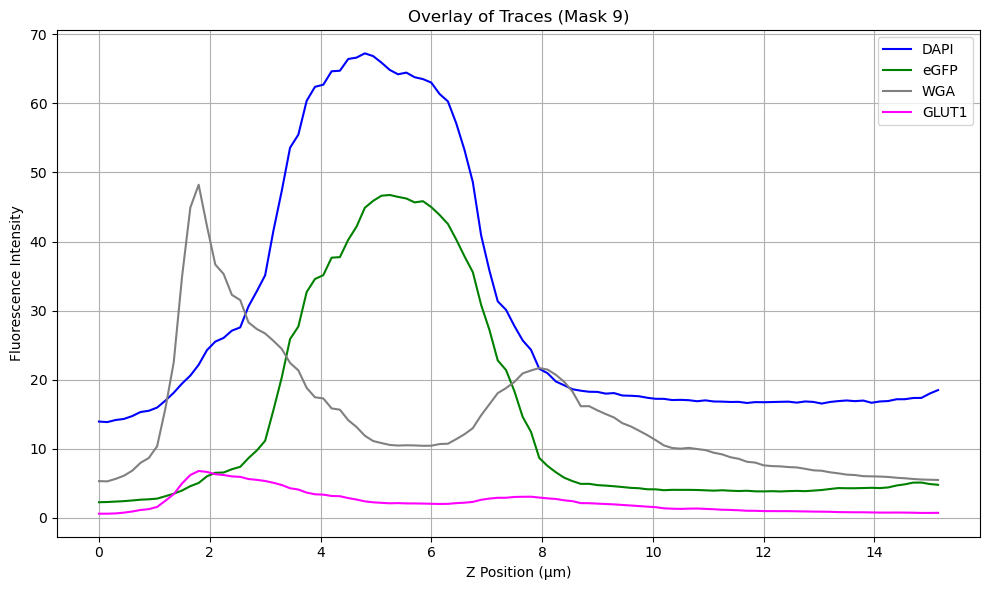

In [80]:

# Convert list-like strings
cleaned_df = convert_list_strings_to_lists(data)

# 🔧 Choose which mask (row index) to visualize
MASK_INDEX = 7  # <--- Change this to select a different mask (e.g., 1, 2, 5, ...)

# Get the selected row
row = cleaned_df.dropna(subset=["X_vals", "Y_vals_DAPI", "Y_vals_eGFP", "Y_vals_WGA", "Y_vals_GLUT1"]).iloc[MASK_INDEX]

x_vals = row["X_vals"]
traces = {
    "DAPI": row["Y_vals_DAPI"],
    "eGFP": row["Y_vals_eGFP"],
    "WGA": row["Y_vals_WGA"],
    "GLUT1": row["Y_vals_GLUT1"],
}

# 🎨 Customize trace colors here
colors = {
    "DAPI": "blue",
    "eGFP": "green",
    "WGA": "grey",
    "GLUT1": "magenta"
}

# Plot
plt.figure(figsize=(10, 6))
for stain, y_vals in traces.items():
    plt.plot(x_vals, y_vals, label=stain, color=colors.get(stain, None))

plt.xlabel("Z Position (µm)")
plt.ylabel("Fluorescence Intensity")
plt.title(f"Overlay of Traces (Mask {row['mask_id']})")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()